In [ ]:
!pip install gymnasium
!pip install gymnasium[toy-text]
!pip install torch

In [ ]:

import gymnasium as gym
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
from collections import deque
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time


In [ ]:
# --- Custom Reward Wrapper for Potential-Based Shaping + Revisit Penalty ---
class CustomRewardWrapper(gym.Wrapper):
    """
    Adds potential-based reward shaping AND a revisit penalty.
    Revisit penalty discourages loops; shaping preserves value structure.
    """

    def __init__(self, env, revisit_penalty=-0.05):
        super().__init__(env)

        # ---- existing variables ----
        self.map_size = int(np.sqrt(env.observation_space.n))
        self.goal_pos = (self.map_size - 1, self.map_size - 1)
        self.last_distance = None
        self.gamma = 0.99

        # ---- NEW: loop-avoidance mechanism ----
        self.revisit_penalty = revisit_penalty
        self.visited_states = set()

    def _get_distance_to_goal(self, state):
        row = state // self.map_size
        col = state % self.map_size
        return abs(row - self.goal_pos[0]) + abs(col - self.goal_pos[1])

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)

        # store distance for shaping
        self.last_distance = self._get_distance_to_goal(obs)

        # NEW: reset visited states
        self.visited_states = {obs}

        return obs, info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        current_distance = self._get_distance_to_goal(obs)

        # ---------- Potential-Based Shaping ----------
        original_reward = reward
        potential_current = -current_distance
        potential_last = -self.last_distance
        shaping_term = self.gamma * potential_current - potential_last
        shaped_reward = original_reward + shaping_term

        # ---------- Revisit Penalty (NEW) ----------
        if obs in self.visited_states:
            shaped_reward += self.revisit_penalty
        else:
            self.visited_states.add(obs)

        # update distance
        self.last_distance = current_distance

        return obs, shaped_reward, terminated, truncated, info


In [ ]:

# --- Deep SARSA Classes ---

class QNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        # Input size is 16 for 4x4 FrozenLake (one-hot encoded)
        self.net = nn.Sequential(
            nn.Linear(16, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 4) # Output size is 4 for 4 actions
        )

    def forward(self, x):
        return self.net(x)


def one_hot(state, size=16):
    """Converts a discrete state index to a one-hot vector."""
    v = np.zeros(size)
    v[state] = 1
    return torch.tensor(v, dtype=torch.float32)


class ReplayBuffer:
    def __init__(self, capacity=50000):
        self.buffer = deque(maxlen=capacity)

    def push(self, s, a, r, sp, ap, done):
        """Stores a transition (S, A, R, S', A', done) including the next action (A')."""
        self.buffer.append((s, a, r, sp, ap, done))

    def sample(self, batch_size=64):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, sp, ap, done = zip(*batch)
        return (
            torch.stack(s),
            torch.tensor(a),
            torch.tensor(r, dtype=torch.float32),
            torch.stack(sp),
            torch.tensor(ap),
            torch.tensor(done, dtype=torch.int)
        )

    def __len__(self):
        return len(self.buffer)


class DeepSARSA:
    def __init__(self, lr=0.001, gamma=0.995):
        self.q_net = QNetwork()
        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)
        self.gamma = gamma
        self.buffer = ReplayBuffer()
        self.batch_size = 64

    def act(self, state, eps):
        if random.random() < eps:
            return random.randint(0, 3) # 4 actions: 0, 1, 2, 3
        # Greedy action from Q-network
        q_vals = self.q_net(state.unsqueeze(0))
        return torch.argmax(q_vals).item()

    def store(self, s, a, r, sp, ap, done):
        self.buffer.push(s, a, r, sp, ap, done)

    def train_step(self):
        if len(self.buffer) < self.batch_size:
            return

        s, a, r, sp, ap, done = self.buffer.sample(self.batch_size)

        # Q(S, A) prediction
        q_pred = self.q_net(s)[torch.arange(self.batch_size), a]

        # SARSA Target: R + gamma * Q(S', A')
        with torch.no_grad():
            next_q = self.q_net(sp)[torch.arange(self.batch_size), ap]
            # (1 - done) ensures the target is just R if the episode terminated
            target = r + (1 - done) * self.gamma * next_q

        # Mean Squared Error Loss
        loss = ((q_pred - target)**2).mean()

        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()


# --- Training Setup ---


In [ ]:

# Wrap the environment to include the potential-based reward shaping
base_env = gym.make("FrozenLake-v1", is_slippery=False)
env = CustomRewardWrapper(base_env)
GOAL_STATE = env.observation_space.n - 1 # Goal is always the last state (15 for 4x4)

agent = DeepSARSA()

episodes = 8000
eps = 1.0
eps_min = 0.05
eps_decay = 0.9993

reward_log = []
success_log = [] # New: Log 1 for success, 0 for failure


In [ ]:

print("Training Deep SARSA with Potential-Based Shaping on Non-Slippery FrozenLake...")

for ep in range(episodes):
    s, info = env.reset()
    s_t = one_hot(s)
    a = agent.act(s_t, eps)

    total_reward = 0
    done = False
    episode_success = False # New: Track success per episode

    while not done:
        # The reward returned here is the SHAPED reward from the CustomRewardWrapper
        sp, shaped_reward, terminated, truncated, info = env.step(a)
        done = terminated or truncated

        # Check for success: terminated and landed on the goal state
        if terminated and sp == GOAL_STATE:
            episode_success = True

        # We use the shaped_reward directly (aliased as 'r')
        r = shaped_reward

        sp_t = one_hot(sp)
        ap = agent.act(sp_t, eps)

        agent.store(s_t, a, r, sp_t, ap, done)
        agent.train_step()

        s_t, a = sp_t, ap
        total_reward += r # Log the shaped reward

    # Log results after episode finishes
    success_log.append(1 if episode_success else 0)
    eps = max(eps * eps_decay, eps_min)
    reward_log.append(total_reward)

    if (ep+1) % 1000 == 0:
        avg_reward = np.mean(reward_log[-100:])
        # Calculate success rate as a percentage over the last 100 episodes
        avg_success = np.mean(success_log[-100:]) * 100
        print(f"Episode {ep+1}/{episodes} | eps={eps:.3f} | Last 100 Avg Shaped Reward: {avg_reward:.2f} | Last 100 Success Rate: {avg_success:.2f}%")

print("Training finished!")


Training Deep SARSA with Potential-Based Shaping on Non-Slippery FrozenLake...
Episode 1000/8000 | eps=0.496 | Last 100 Avg Shaped Reward: 4.74 | Last 100 Success Rate: 38.00%
Episode 2000/8000 | eps=0.246 | Last 100 Avg Shaped Reward: 5.79 | Last 100 Success Rate: 67.00%
Episode 3000/8000 | eps=0.122 | Last 100 Avg Shaped Reward: 6.75 | Last 100 Success Rate: 88.00%
Episode 4000/8000 | eps=0.061 | Last 100 Avg Shaped Reward: 6.93 | Last 100 Success Rate: 94.00%
Episode 5000/8000 | eps=0.050 | Last 100 Avg Shaped Reward: 6.87 | Last 100 Success Rate: 92.00%
Episode 6000/8000 | eps=0.050 | Last 100 Avg Shaped Reward: 7.07 | Last 100 Success Rate: 97.00%
Episode 7000/8000 | eps=0.050 | Last 100 Avg Shaped Reward: 6.79 | Last 100 Success Rate: 92.00%
Episode 8000/8000 | eps=0.050 | Last 100 Avg Shaped Reward: 6.85 | Last 100 Success Rate: 92.00%
Training finished!


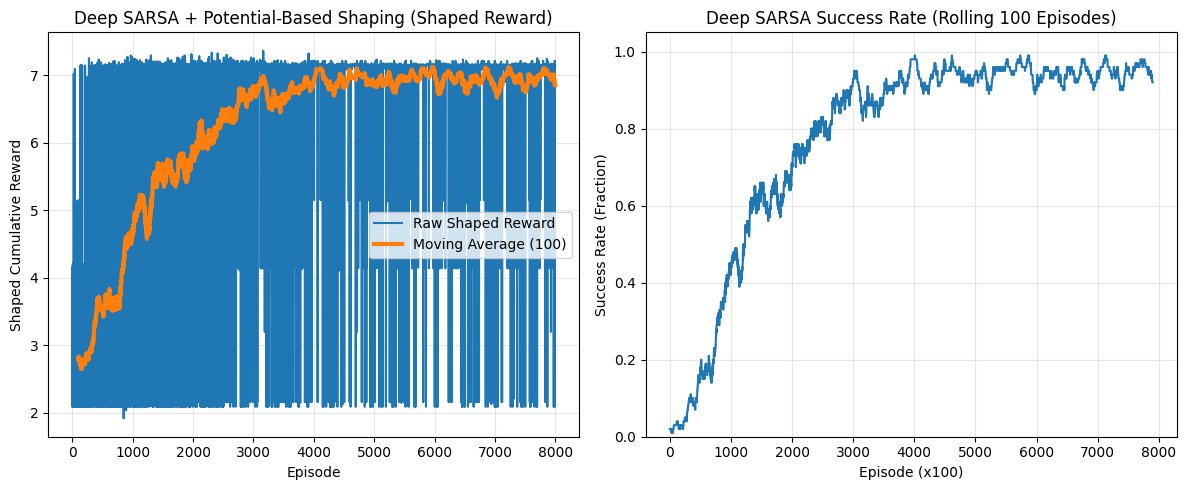

In [ ]:
# --- Plotting Results (Now with two subplots) ---

plt.figure(figsize=(12, 5))

# Subplot 1: Shaped Reward + Moving Average
plt.subplot(1, 2, 1)
plt.plot(reward_log, label="Raw Shaped Reward")

# Moving average window
reward_window = 100
reward_smooth = np.convolve(reward_log, np.ones(reward_window)/reward_window, mode='valid')

plt.plot(range(reward_window-1, reward_window-1 + len(reward_smooth)),
         reward_smooth, linewidth=3, label=f"Moving Average ({reward_window})")

plt.title("Deep SARSA + Potential-Based Shaping (Shaped Reward)")
plt.xlabel("Episode")
plt.ylabel("Shaped Cumulative Reward")
plt.grid(True, alpha=0.3)
plt.legend()

# Subplot 2: Success Rate (Smoothed with a rolling average)
window_size = 100
smoothed_success = np.convolve(success_log, np.ones(window_size)/window_size, mode='valid')

plt.subplot(1, 2, 2)
plt.plot(smoothed_success)
plt.title(f"Deep SARSA Success Rate (Rolling {window_size} Episodes)")
plt.xlabel(f"Episode (x{window_size})")
plt.ylabel("Success Rate (Fraction)")
plt.ylim(0, 1.05)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# -------------------- Reward Wrapper --------------------
class CustomRewardWrapper(gym.Wrapper):
    def __init__(self, env, revisit_penalty=-0.05):
        super().__init__(env)
        self.map_size = int(np.sqrt(env.observation_space.n))
        self.goal_pos = (self.map_size - 1, self.map_size - 1)
        self.last_distance = None
        self.gamma = 0.99

        # new
        self.revisit_penalty = revisit_penalty
        self.visited_states = set()

    def _get_distance_to_goal(self, state):
        row = state // self.map_size
        col = state % self.map_size
        return abs(row - self.goal_pos[0]) + abs(col - self.goal_pos[1])

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self.last_distance = self._get_distance_to_goal(obs)

        # new: track visited states
        self.visited_states = {obs}

        return obs, info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)

        # ---------------------------------------------------------
        # 1. Potential-based shaping (unchanged)
        # ---------------------------------------------------------
        current_distance = self._get_distance_to_goal(obs)
        potential_current = -current_distance
        potential_last = -self.last_distance
        shaping = self.gamma * potential_current - potential_last
        shaped_reward = reward + shaping

        # ---------------------------------------------------------
        # 2. Revisit penalty (NEW)
        # ---------------------------------------------------------
        if obs in self.visited_states:
            shaped_reward += self.revisit_penalty
        else:
            self.visited_states.add(obs)

        # update for next step
        self.last_distance = current_distance

        return obs, shaped_reward, terminated, truncated, info


In [ ]:



# -------------------- Deep SARSA --------------------
class QNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(64, 128),   # <<< CHANGED from 16 → 64
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 4)
        )

    def forward(self, x):
        return self.net(x)


def one_hot(state, size=64):   # <<< CHANGED 16 → 64
    v = np.zeros(size)
    v[state] = 1
    return torch.tensor(v, dtype=torch.float32)



In [ ]:

class ReplayBuffer:
    def __init__(self, capacity=50000):
        self.buffer = deque(maxlen=capacity)

    def push(self, s, a, r, sp, ap, done):
        self.buffer.append((s, a, r, sp, ap, done))

    def sample(self, batch_size=64):
        batch = random.sample(self.buffer, batch_size)
        s, a, r, sp, ap, done = zip(*batch)
        return (
            torch.stack(s),
            torch.tensor(a),
            torch.tensor(r, dtype=torch.float32),
            torch.stack(sp),
            torch.tensor(ap),
            torch.tensor(done, dtype=torch.int)
        )

    def __len__(self):
        return len(self.buffer)



In [ ]:

class DeepSARSA:
    def __init__(self, lr=0.001, gamma=0.995):
        self.q_net = QNetwork()
        self.optimizer = optim.Adam(self.q_net.parameters(), lr=lr)
        self.gamma = gamma
        self.buffer = ReplayBuffer()
        self.batch_size = 64

    def act(self, state, eps):
        if random.random() < eps:
            return random.randint(0, 3)
        q_vals = self.q_net(state.unsqueeze(0))
        return torch.argmax(q_vals).item()

    def store(self, s, a, r, sp, ap, done):
        self.buffer.push(s, a, r, sp, ap, done)

    def train_step(self):
        if len(self.buffer) < self.batch_size:
            return

        s, a, r, sp, ap, done = self.buffer.sample(self.batch_size)
        q_pred = self.q_net(s)[torch.arange(self.batch_size), a]

        with torch.no_grad():
            next_q = self.q_net(sp)[torch.arange(self.batch_size), ap]
            target = r + (1 - done) * self.gamma * next_q

        loss = ((q_pred - target)**2).mean()
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()



In [ ]:


# -------------------- Environment Setup (8×8) --------------------
base_env = gym.make("FrozenLake-v1", map_name="8x8", is_slippery=False)
env = CustomRewardWrapper(base_env)

GOAL_STATE = env.observation_space.n - 1   # now 63

agent = DeepSARSA()

episodes = 8000
eps = 1.0
eps_min = 0.05
eps_decay = 0.9993

reward_log = []
success_log = []

print("Training Deep SARSA on FrozenLake 8x8...\n")


Training Deep SARSA on FrozenLake 8x8...



In [ ]:


# -------------------- Training Loop --------------------
for ep in range(episodes):
    s, info = env.reset()
    s_t = one_hot(s)
    a = agent.act(s_t, eps)

    total_reward = 0
    done = False
    success = False

    while not done:
        sp, shaped_reward, terminated, truncated, info = env.step(a)
        done = terminated or truncated

        if terminated and sp == GOAL_STATE:
            success = True

        r = shaped_reward
        sp_t = one_hot(sp)
        ap = agent.act(sp_t, eps)

        agent.store(s_t, a, r, sp_t, ap, done)
        agent.train_step()

        s_t, a = sp_t, ap
        total_reward += r

    success_log.append(1 if success else 0)
    reward_log.append(total_reward)
    eps = max(eps * eps_decay, eps_min)

    if (ep+1) % 1000 == 0:
        print(f"Episode {ep+1}/{episodes} | eps={eps:.3f}")


print("Training complete!")




Episode 1000/8000 | eps=0.496
Episode 2000/8000 | eps=0.246
Episode 3000/8000 | eps=0.122
Episode 4000/8000 | eps=0.061
Episode 5000/8000 | eps=0.050
Episode 6000/8000 | eps=0.050
Episode 7000/8000 | eps=0.050
Episode 8000/8000 | eps=0.050
Training complete!


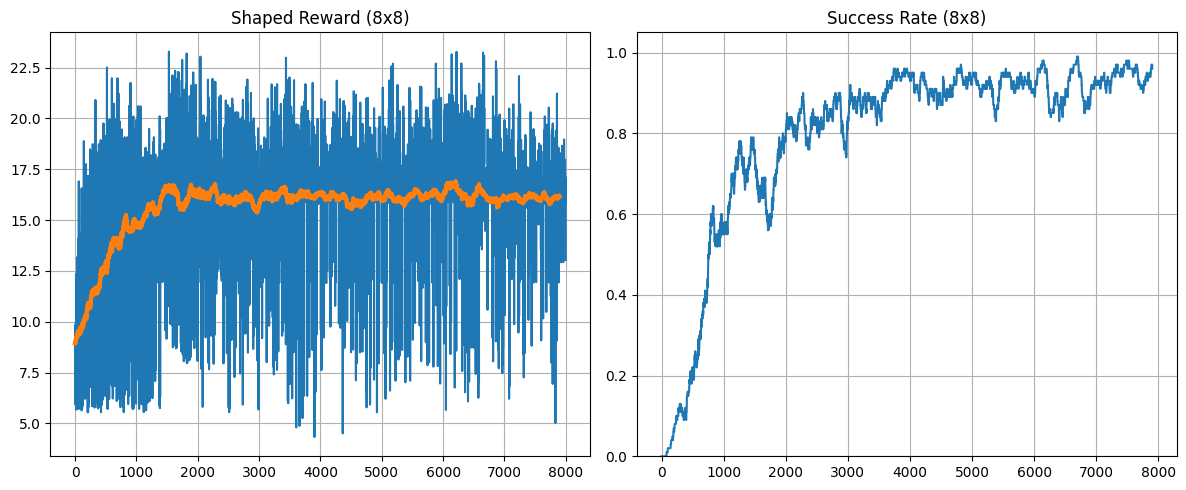

In [ ]:

# -------------------- Plots --------------------
plt.figure(figsize=(12,5))

# Reward plot + smoothing
plt.subplot(1,2,1)
plt.plot(reward_log)
smooth_r = np.convolve(reward_log, np.ones(100)/100, mode='valid')
plt.plot(smooth_r, linewidth=3)
plt.title("Shaped Reward (8x8)")
plt.grid()

# Success plot
plt.subplot(1,2,2)
smooth_s = np.convolve(success_log, np.ones(100)/100, mode='valid')
plt.plot(smooth_s)
plt.title("Success Rate (8x8)")
plt.ylim(0,1.05)
plt.grid()

plt.tight_layout()
plt.show()



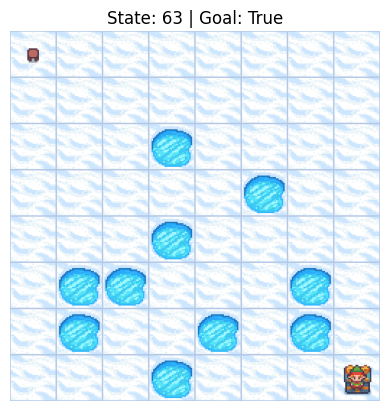

In [ ]:

# -------------------- Evaluation Run --------------------
base_env_render = gym.make("FrozenLake-v1", map_name="8x8", is_slippery=False, render_mode="rgb_array")
env_render = CustomRewardWrapper(base_env_render)

s, info = env_render.reset()
done = False

print("\n--- Evaluation Run (Greedy) ---")
time.sleep(1)

while not done:
    s_t = one_hot(s)
    a = agent.act(s_t, eps=0.0)

    s, r, terminated, truncated, info = env_render.step(a)
    done = terminated or truncated

    frame = env_render.render()
    clear_output(wait=True)
    plt.imshow(frame)
    plt.title(f"State: {s} | Goal: {s==GOAL_STATE}")
    plt.axis("off")
    plt.show()
    time.sleep(0.25)

env_render.close()


16x16 FrozenLake Deep SARSA Training (Improved)
Map size: 16x16
States: 256, Actions: 4
Slippery: True
Device: cuda

Starting training...
----------------------------------------------------------------------
Ep  100 | Success: 0.00% | Best: 0.00% | AvgRew: 1.33 | AvgLen: 35.2 | SuccSteps: 0.0 | Eps: 0.960 | LR: 0.000999
Ep  200 | Success: 16.00% | Best: 16.00% | AvgRew: 1.33 | AvgLen: 35.3 | SuccSteps: 201.1 | Eps: 0.921 | LR: 0.000996
Ep  300 | Success: 0.00% | Best: 16.00% | AvgRew: 1.36 | AvgLen: 33.6 | SuccSteps: 0.0 | Eps: 0.881 | LR: 0.000991
Ep  400 | Success: 0.00% | Best: 16.00% | AvgRew: 1.54 | AvgLen: 46.1 | SuccSteps: 0.0 | Eps: 0.842 | LR: 0.000984
Ep  500 | Success: 2.00% | Best: 16.00% | AvgRew: 1.48 | AvgLen: 39.5 | SuccSteps: 119.0 | Eps: 0.802 | LR: 0.000976
Ep  600 | Success: 16.00% | Best: 16.00% | AvgRew: 1.55 | AvgLen: 44.9 | SuccSteps: 233.6 | Eps: 0.762 | LR: 0.000965
Ep  700 | Success: 12.00% | Best: 16.00% | AvgRew: 1.62 | AvgLen: 48.4 | SuccSteps: 237.5 | Ep

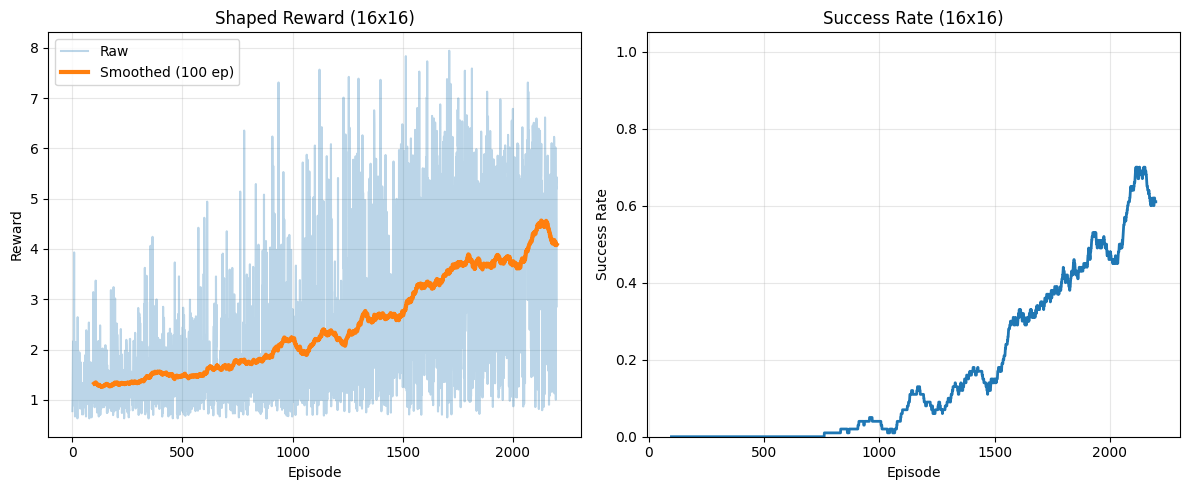

In [ ]:
# Improved Deep SARSA for 16x16 FrozenLake
import random
from collections import deque
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym
from gymnasium.envs.toy_text.frozen_lake import FrozenLakeEnv
import matplotlib.pyplot as plt
from IPython.display import clear_output
import time

# ---------------------------
# 16x16 Custom Map
# ---------------------------
CUSTOM_MAP = [
    "SFFFFFFFFFFFFFFF",
    "FFFFFFFFFFFFFFFF",
    "FFFHFFFFFFFHFFFF",
    "FFFFFHFFFFFFFFFF",
    "FFFFFFFFFFFFFFFF",
    "FHHFFFHFFFFFFFFF",
    "FHFFHFFFFFFHFFFF",
    "FFFHFFFFFFFFFFFF",
    "FFFFFHFFFFFFFFFF",
    "FFFFFFFFFFFFFFFF",
    "FFHFFFFFFHFFFFFF",
    "FFFFFHFFFFFFFFFF",
    "FFFHFFFFFFFFFFFF",
    "FHHFFFHFFFFFFFFF",
    "FHFFHFFFFFFFFFFF",
    "FFFFFFFFFFFFFFFG"
]

# ---------------------------
# Improved Reward Wrapper
# ---------------------------
class CustomRewardWrapper(gym.Wrapper):
    def __init__(self, env, revisit_penalty=-0.01, gamma=0.99, distance_scale=0.1):
        super().__init__(env)
        self.map_size = int(np.sqrt(env.observation_space.n))
        self.gamma = gamma
        self.distance_scale = distance_scale

        # Find goal
        self.goal_pos = None
        desc = env.unwrapped.desc
        for i, row in enumerate(desc):
            for j, cell in enumerate(row):
                if cell == b'G':
                    self.goal_pos = (i, j)
                    break
            if self.goal_pos:
                break

        if self.goal_pos is None:
            self.goal_pos = (self.map_size - 1, self.map_size - 1)

        self.last_distance = None
        self.revisit_penalty = revisit_penalty
        self.visited_states = set()

    def _get_distance_to_goal(self, state):
        row = state // self.map_size
        col = state % self.map_size
        return abs(row - self.goal_pos[0]) + abs(col - self.goal_pos[1])

    def reset(self, **kwargs):
        obs, info = self.env.reset(**kwargs)
        self.last_distance = self._get_distance_to_goal(int(obs))
        self.visited_states = {int(obs)}
        return obs, info

    def step(self, action):
        obs, reward, terminated, truncated, info = self.env.step(action)
        obs = int(obs)
        current_distance = self._get_distance_to_goal(obs)

        # Potential-based shaping with larger scale
        potential_current = -current_distance * self.distance_scale
        potential_last = -self.last_distance * self.distance_scale
        shaping_term = self.gamma * potential_current - potential_last

        shaped_reward = reward + shaping_term

        # Revisit penalty
        if obs in self.visited_states:
            shaped_reward += self.revisit_penalty
        else:
            self.visited_states.add(obs)

        self.last_distance = current_distance
        return obs, shaped_reward, terminated, truncated, info

# ---------------------------
# More Efficient Q-Network
# ---------------------------
class QNetwork(nn.Module):
    def __init__(self, n_states: int, n_actions: int):
        super().__init__()
        # Use embedding instead of one-hot for efficiency
        self.embedding = nn.Embedding(n_states, 128)
        self.net = nn.Sequential(
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, n_actions)
        )

        # Initialize
        nn.init.normal_(self.embedding.weight, std=0.01)
        for layer in self.net:
            if isinstance(layer, nn.Linear):
                nn.init.orthogonal_(layer.weight, gain=np.sqrt(2))
                nn.init.constant_(layer.bias, 0.0)

    def forward(self, states):
        # states should be LongTensor of state indices
        x = self.embedding(states)
        return self.net(x)

# ---------------------------
# Standard Replay Buffer (for true on-policy, use n-step)
# ---------------------------
class ReplayBuffer:
    def __init__(self, capacity: int = 50000):
        self.buffer = deque(maxlen=capacity)

    def push(self, s, a, r, s2, a2, done):
        self.buffer.append((s, a, r, s2, a2, done))

    def sample(self, batch_size: int):
        return random.sample(self.buffer, min(batch_size, len(self.buffer)))

    def __len__(self):
        return len(self.buffer)

# ---------------------------
# Helper Functions
# ---------------------------
def get_goal_state(env):
    """Find the goal state in the environment"""
    map_size = len(env.unwrapped.desc)
    for i, row in enumerate(env.unwrapped.desc):
        for j, cell in enumerate(row):
            if cell == b'G':
                return i * map_size + j
    return map_size * map_size - 1

def evaluate_agent(qnet, env, device, n_episodes=50, max_steps=500, render=False):
    qnet.eval()
    successes = 0
    total_rewards = []
    total_steps = []
    goal_state = get_goal_state(env)

    for ep in range(n_episodes):
        obs, _ = env.reset()
        state = int(obs)
        episode_reward = 0

        for step in range(max_steps):
            if render and ep == 0:
                print(f"Step {step}: State {state}")

            with torch.no_grad():
                state_t = torch.tensor([state], dtype=torch.long, device=device)
                q_values = qnet(state_t)
                action = q_values.argmax().item()

            obs, reward, terminated, truncated, info = env.step(action)
            episode_reward += reward
            state = int(obs)

            if terminated or truncated:
                if state == goal_state:
                    successes += 1
                    total_steps.append(step + 1)
                    if render and ep == 0:
                        print(f"✓ SUCCESS! Reached goal in {step+1} steps")
                elif render and ep == 0:
                    print(f"✗ Failed (fell in hole) at step {step+1}")
                break

        total_rewards.append(episode_reward)

    qnet.train()
    success_rate = successes / n_episodes
    avg_reward = np.mean(total_rewards)
    avg_steps = np.mean(total_steps) if total_steps else 0
    return success_rate, avg_reward, avg_steps

# ---------------------------
# True SARSA Training
# ---------------------------
def train_sarsa(map_desc,
                n_episodes=5000,
                max_steps=500,
                learning_rate=0.001,
                gamma=0.99,
                epsilon_start=1.0,
                epsilon_end=0.01,
                epsilon_decay=2500,
                batch_size=128,
                target_update=10,
                eval_every=100,
                distance_scale=0.1,
                is_slippery=True,
                device='cpu',
                seed=42,
                warmup_steps=256):

    # Set seeds
    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)

    # Create environment
    env = FrozenLakeEnv(desc=map_desc, is_slippery=is_slippery)
    env = CustomRewardWrapper(env, revisit_penalty=-0.01, gamma=gamma, distance_scale=distance_scale)

    n_states = env.observation_space.n
    n_actions = env.action_space.n
    map_size = len(map_desc)

    print("="*70)
    print(f"16x16 FrozenLake Deep SARSA Training (Improved)")
    print("="*70)
    print(f"Map size: {map_size}x{map_size}")
    print(f"States: {n_states}, Actions: {n_actions}")
    print(f"Slippery: {is_slippery}")
    print(f"Device: {device}")
    print("="*70 + "\n")

    # Initialize networks
    device = torch.device(device)
    qnet = QNetwork(n_states, n_actions).to(device)
    target_net = QNetwork(n_states, n_actions).to(device)
    target_net.load_state_dict(qnet.state_dict())
    target_net.eval()

    optimizer = optim.AdamW(qnet.parameters(), lr=learning_rate, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_episodes, eta_min=1e-6)

    replay_buffer = ReplayBuffer(capacity=50000)
    loss_fn = nn.SmoothL1Loss()

    epsilon = epsilon_start
    best_success = 0.0
    episode_rewards = []
    episode_lengths = []
    success_log = []  # Track success per episode

    print("Starting training...")
    print("-" * 70)

    for episode in range(1, n_episodes + 1):
        obs, _ = env.reset()
        state = int(obs)

        # Select first action (epsilon-greedy)
        with torch.no_grad():
            state_t = torch.tensor([state], dtype=torch.long, device=device)
            q_values = qnet(state_t)
            if random.random() < epsilon:
                action = random.randrange(n_actions)
            else:
                action = q_values.argmax().item()

        episode_reward = 0
        episode_length = 0

        for step in range(max_steps):
            # Take action
            obs, reward, terminated, truncated, info = env.step(action)
            done = terminated or truncated
            next_state = int(obs)

            episode_reward += reward
            episode_length += 1

            # Select ACTUAL next action (this is SARSA)
            with torch.no_grad():
                next_state_t = torch.tensor([next_state], dtype=torch.long, device=device)
                next_q = qnet(next_state_t)
                if random.random() < epsilon:
                    next_action = random.randrange(n_actions)
                else:
                    next_action = next_q.argmax().item()

            # Store transition
            replay_buffer.push(state, action, reward, next_state, next_action, done)

            # Train after warmup
            if len(replay_buffer) >= warmup_steps:
                batch = replay_buffer.sample(batch_size)

                # Convert to tensors
                states = torch.tensor([s for s, _, _, _, _, _ in batch], dtype=torch.long, device=device)
                actions = torch.tensor([a for _, a, _, _, _, _ in batch], dtype=torch.long, device=device)
                rewards = torch.tensor([r for _, _, r, _, _, _ in batch], dtype=torch.float32, device=device)
                next_states = torch.tensor([s2 for _, _, _, s2, _, _ in batch], dtype=torch.long, device=device)
                next_actions = torch.tensor([a2 for _, _, _, _, a2, _ in batch], dtype=torch.long, device=device)
                dones = torch.tensor([d for _, _, _, _, _, d in batch], dtype=torch.float32, device=device)

                # Q(s, a)
                q_vals = qnet(states)
                q_sa = q_vals.gather(1, actions.unsqueeze(1)).squeeze()

                # SARSA target: r + gamma * Q_target(s', a')
                with torch.no_grad():
                    next_q_vals = target_net(next_states)
                    next_q_sa = next_q_vals.gather(1, next_actions.unsqueeze(1)).squeeze()
                    targets = rewards + gamma * next_q_sa * (1 - dones)

                # Update
                loss = loss_fn(q_sa, targets)
                optimizer.zero_grad()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(qnet.parameters(), 1.0)
                optimizer.step()

            # Move to next state-action pair
            state = next_state
            action = next_action

            if done:
                break

        episode_rewards.append(episode_reward)
        episode_lengths.append(episode_length)

        # Track if this episode was successful
        goal_state = get_goal_state(env)
        success_log.append(1.0 if state == goal_state else 0.0)

        # Update target network
        if episode % target_update == 0:
            target_net.load_state_dict(qnet.state_dict())

        # Decay epsilon
        if episode < epsilon_decay:
            epsilon = epsilon_start - (epsilon_start - epsilon_end) * (episode / epsilon_decay)
        else:
            epsilon = epsilon_end

        # Step scheduler
        scheduler.step()

        # Evaluation
        if episode % eval_every == 0:
            success_rate, avg_reward, avg_steps = evaluate_agent(qnet, env, device, n_episodes=50)
            recent_reward = np.mean(episode_rewards[-eval_every:])
            recent_length = np.mean(episode_lengths[-eval_every:])
            current_lr = optimizer.param_groups[0]['lr']

            if success_rate > best_success:
                best_success = success_rate
                torch.save(qnet.state_dict(), 'best_sarsa_16x16.pth')

            print(f"Ep {episode:4d} | Success: {success_rate:.2%} | Best: {best_success:.2%} | "
                  f"AvgRew: {recent_reward:.2f} | AvgLen: {recent_length:.1f} | "
                  f"SuccSteps: {avg_steps:.1f} | Eps: {epsilon:.3f} | LR: {current_lr:.6f}")

            # Early stopping
            if success_rate >= 0.95:
                print(f"\n🎉 Agent achieved {success_rate:.1%} success rate!")
                break

    env.close()

    # Final evaluation
    print("\n" + "="*70)
    print("FINAL EVALUATION (100 episodes)")
    print("="*70)
    eval_env = FrozenLakeEnv(desc=map_desc, is_slippery=is_slippery)
    eval_env = CustomRewardWrapper(eval_env, revisit_penalty=-0.01, gamma=gamma, distance_scale=distance_scale)
    final_success, final_reward, final_steps = evaluate_agent(qnet, eval_env, device, n_episodes=100, render=True)
    print(f"\nFinal Success Rate: {final_success:.2%}")
    print(f"Final Avg Reward: {final_reward:.2f}")
    print(f"Final Avg Steps (successful): {final_steps:.1f}")
    print(f"Best Success Rate: {best_success:.2%}")
    eval_env.close()

    return qnet, episode_rewards, success_log

# ---------------------------
# Main
# ---------------------------
if __name__ == "__main__":
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    qnet, rewards, success_log = train_sarsa(
        map_desc=CUSTOM_MAP,
        n_episodes=5000,
        max_steps=500,
        learning_rate=0.001,
        gamma=0.99,
        epsilon_start=1.0,
        epsilon_end=0.01,
        epsilon_decay=2500,
        batch_size=128,
        target_update=10,
        eval_every=100,
        distance_scale=0.1,
        is_slippery=True,
        device=device,
        seed=42,
        warmup_steps=256
    )

    print("\n✓ Training complete!")
    print("Best model saved to: best_sarsa_16x16.pth")

    # -------------------- Plots --------------------
    print("\nGenerating training plots...")
    plt.figure(figsize=(12, 5))

    # Reward plot + smoothing
    plt.subplot(1, 2, 1)
    plt.plot(rewards, alpha=0.3, label='Raw')
    if len(rewards) > 100:
        smooth_r = np.convolve(rewards, np.ones(100)/100, mode='valid')
        plt.plot(range(99, 99 + len(smooth_r)), smooth_r, linewidth=3, label='Smoothed (100 ep)')
    plt.title("Shaped Reward (16x16)")
    plt.xlabel("Episode")
    plt.ylabel("Reward")
    plt.legend()
    plt.grid(True, alpha=0.3)

    # Success plot
    plt.subplot(1, 2, 2)
    if len(success_log) > 100:
        smooth_s = np.convolve(success_log, np.ones(100)/100, mode='valid')
        plt.plot(range(99, 99 + len(smooth_s)), smooth_s, linewidth=2)
    else:
        plt.plot(success_log)
    plt.title("Success Rate (16x16)")
    plt.xlabel("Episode")
    plt.ylabel("Success Rate")
    plt.ylim(0, 1.05)
    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_plots_16x16.png', dpi=150, bbox_inches='tight')
    print("Plots saved to: training_plots_16x16.png")
    plt.show()



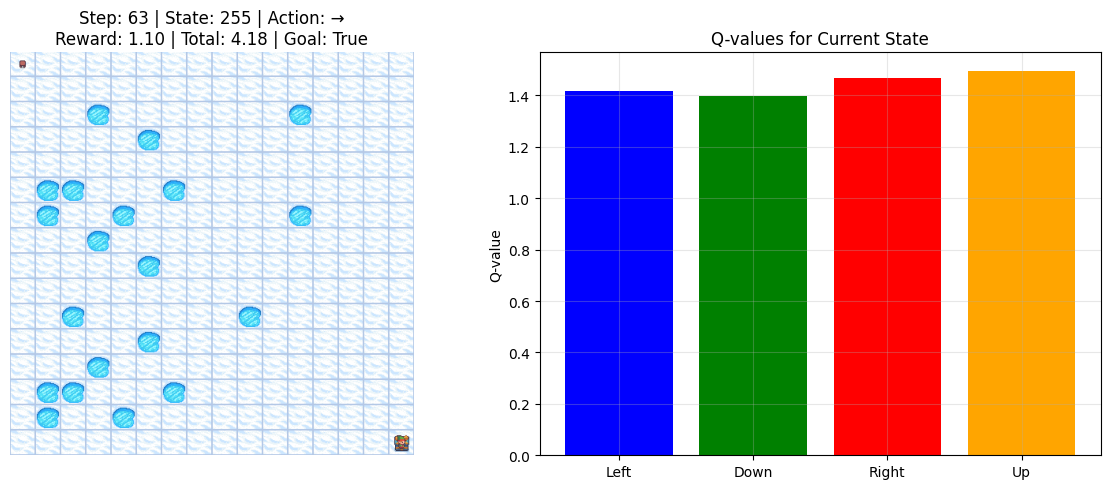


----------------------------------------------------------------------
✓ SUCCESS! Reached goal in 63 steps
Total reward: 4.18
Trajectory length: 64
Unique states visited: 31
----------------------------------------------------------------------


In [ ]:
# -------------------- Evaluation Run with Visualization --------------------
print("\n" + "="*70)
print("VISUAL EVALUATION RUN (Greedy Policy)")
print("="*70)

    # Create environment with rendering
render_env = FrozenLakeEnv(desc=CUSTOM_MAP, is_slippery=False, render_mode="rgb_array")
render_env = CustomRewardWrapper(render_env, revisit_penalty=-0.01, gamma=0.99, distance_scale=0.1)

s, info = render_env.reset()
s = int(s)
done = False
step_count = 0
total_reward = 0
goal_state = get_goal_state(render_env)

print(f"Starting from state: {s}")
print(f"Goal state: {goal_state}")
time.sleep(1)

trajectory = [s]

while not done and step_count < 500:
    # Get action from trained network (greedy)
    with torch.no_grad():
        s_t = torch.tensor([s], dtype=torch.long, device=device)
        q_values = qnet(s_t)
        a = q_values.argmax().item()

    # Take action
    s_next, r, terminated, truncated, info = render_env.step(a)
    s_next = int(s_next)
    done = terminated or truncated
    total_reward += r
    step_count += 1
    trajectory.append(s_next)

    # Render current state
    frame = render_env.render()
    clear_output(wait=True)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Display game state
    ax1.imshow(frame)
    action_names = ['←', '↓', '→', '↑']
    ax1.set_title(f"Step: {step_count} | State: {s_next} | Action: {action_names[a]}\n"
                 f"Reward: {r:.2f} | Total: {total_reward:.2f} | Goal: {s_next == goal_state}",
                 fontsize=12)
    ax1.axis("off")

    # Display Q-values
    with torch.no_grad():
        s_tensor = torch.tensor([s_next], dtype=torch.long, device=device)
        q_vals = qnet(s_tensor).cpu().numpy()[0]

    ax2.bar(range(4), q_vals, color=['blue', 'green', 'red', 'orange'])
    ax2.set_xticks(range(4))
    ax2.set_xticklabels(['Left', 'Down', 'Right', 'Up'])
    ax2.set_ylabel('Q-value')
    ax2.set_title('Q-values for Current State')
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    s = s_next
    time.sleep(0.3)

render_env.close()

# Print final results
print("\n" + "-"*70)
if s == goal_state:
    print(f"✓ SUCCESS! Reached goal in {step_count} steps")
else:
    print(f"✗ Failed after {step_count} steps")
print(f"Total reward: {total_reward:.2f}")
print(f"Trajectory length: {len(trajectory)}")
print(f"Unique states visited: {len(set(trajectory))}")
print("-"*70)
